In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df_holdout = pd.read_parquet("../data/df_holdout.parquet")

In [12]:
E_holdout = df_holdout["Energy"]
Xs_holdout = df_holdout["CrossSection"]

In [2]:
import h5py
import pandas as pd

def extract_mt18_fission_to_df(file_path, nuclide="U235", temperature="294K"):
    with h5py.File(file_path, "r") as f:
        energy = f[f"{nuclide}/energy/{temperature}"][:]
        xs = f[f"{nuclide}/reactions/reaction_018/{temperature}/xs"][:]

    df = pd.DataFrame({
        "Energy": energy,
        "CrossSection": xs
    })
    return df

# Example
df_fission = extract_mt18_fission_to_df("/Users/nickcampbell/ENDF_B-VIII.1_neutron/U235.h5", temperature="294K")
print(df_fission.head())

     Energy  CrossSection
0  0.000010      31434.59
1  0.000010      30954.60
2  0.000011      30495.95
3  0.000011      30057.09
4  0.000011      29636.65


In [4]:
E_eval = df_fission["Energy"]
Xs_eval = df_fission["CrossSection"]

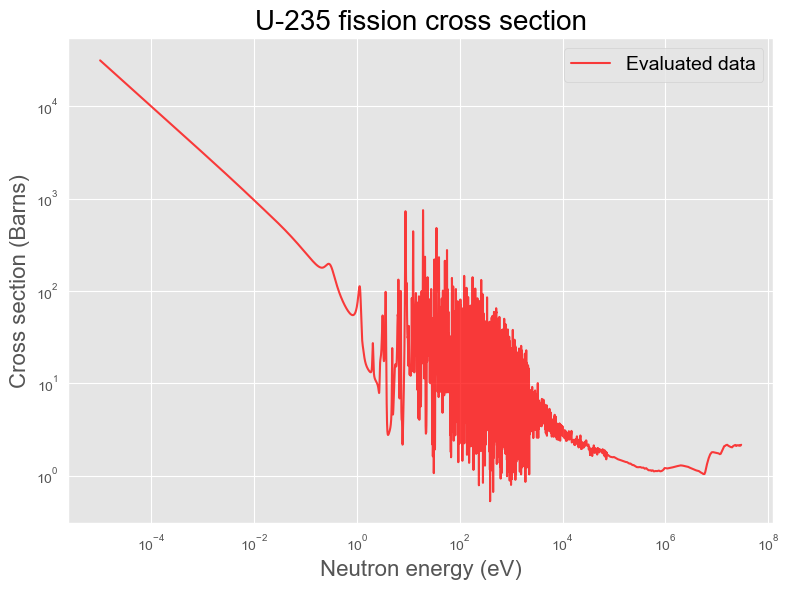

In [5]:
plt.style.use("ggplot")

plt.figure(figsize=(8, 6))


plt.plot(E_eval, Xs_eval, label="Evaluated data", alpha=0.75, color='red')
plt.xscale("log")
plt.yscale("log")

plt.title("U-235 fission cross section", color="black", fontsize=20)
plt.xlabel("Neutron energy (eV)", fontsize=16)
plt.ylabel("Cross section (Barns)", fontsize=16)
plt.legend(loc="upper left")
plt.tight_layout()

plt.legend(labelcolor='black', fontsize=14)
plt.savefig("fig1.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
df_pluto = extract_mt18_fission_to_df("/Users/nickcampbell/ENDF_B-VIII.1_neutron/Pu239.h5", nuclide="Pu239", temperature="294K")
print(df_fission.head())

E_pluto = df_pluto["Energy"]
Xs_pluto = df_pluto["CrossSection"]

     Energy  CrossSection
0  0.000010      31434.59
1  0.000010      30954.60
2  0.000011      30495.95
3  0.000011      30057.09
4  0.000011      29636.65


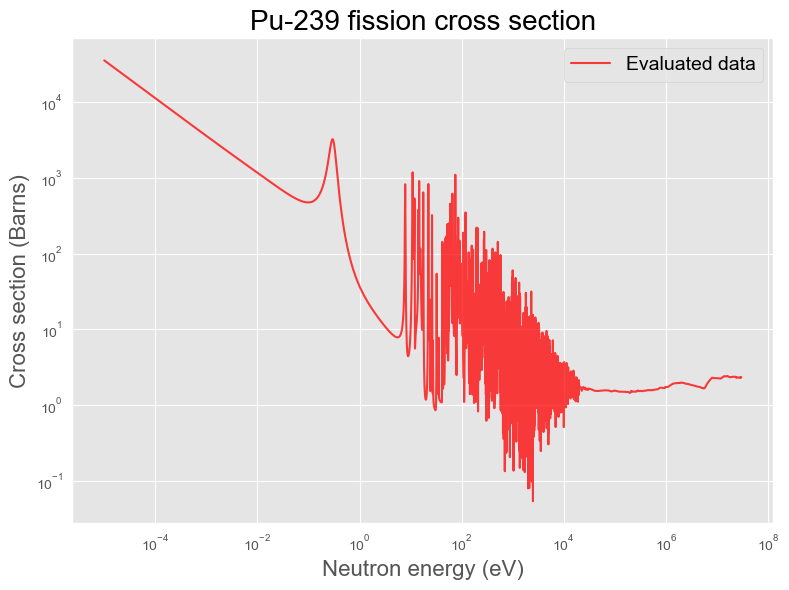

In [15]:
plt.style.use("ggplot")

plt.figure(figsize=(8, 6))


plt.plot(E_pluto, Xs_pluto, label="Evaluated data", alpha=0.75, color='red')

plt.xscale("log")
plt.yscale("log")

plt.title("Pu-239 fission cross section", color="black", fontsize=20)
plt.xlabel("Neutron energy (eV)", fontsize=16)
plt.ylabel("Cross section (Barns)", fontsize=16)
plt.legend(loc="upper left")
plt.tight_layout()

plt.legend(labelcolor='black', fontsize=14)
plt.savefig("fig2.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
df_holdout_thermal = pd.read_parquet("../data/df_holdout_thermal.parquet")
E_thermal = df_holdout_thermal["Energy"]
Xs_thermal = df_holdout_thermal["CrossSection"]
df_pred_xgb = pd.read_csv("../U235_thermal_pred.csv")
E_pred_xgb = df_pred_xgb["Energy"]
Xs_pred_xgb = df_pred_xgb["Predicted_CrossSection"]
df__pred_nn = pd.read_csv("../u235thermal_NN.csv")
E_pred_nn = df__pred_nn["Energy"]
Xs_pred_nn = df__pred_nn["Predicted_CrossSection"]
df_eval_thermal = df_fission[(df_fission["Energy"] <= 1) & (df_fission["Energy"] >= 10**-3)]
E_eval = df_eval_thermal["Energy"]
Xs_eval = df_eval_thermal["CrossSection"]

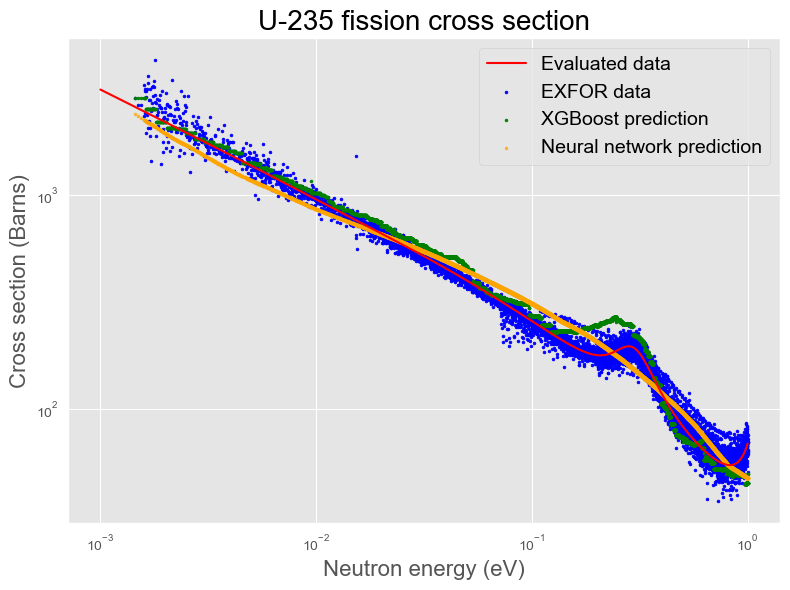

In [36]:
plt.style.use("ggplot")
plt.figure(figsize=(8, 6))


plt.plot(E_eval, Xs_eval, label="Evaluated data", color='red')
plt.scatter(E_thermal, Xs_thermal, s=4, label="EXFOR data", color='blue')
plt.scatter(E_pred_xgb, Xs_pred_xgb, s=4, label="XGBoost prediction", color='green')
plt.scatter(E_pred_nn, Xs_pred_nn, s=4,  label="Neural network prediction", alpha=0.75, color='orange')


plt.xscale("log")
plt.yscale("log")

plt.title("U-235 fission cross section", color="black", fontsize=20)
plt.xlabel("Neutron energy (eV)", fontsize=16)
plt.ylabel("Cross section (Barns)", fontsize=16)
plt.tight_layout()

plt.legend(labelcolor='black', fontsize=14)
plt.savefig("fig3.png", dpi=300, bbox_inches="tight")
plt.show()

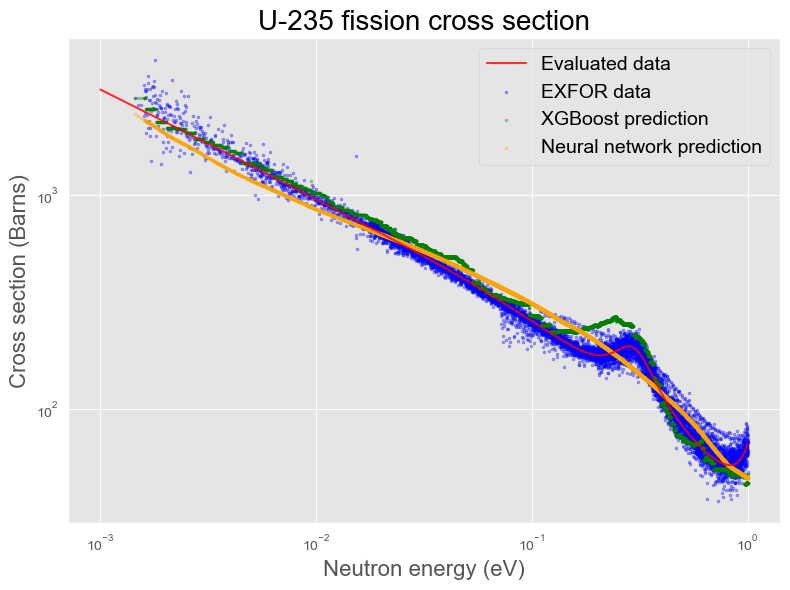

In [38]:
plt.style.use("ggplot")
plt.figure(figsize=(8, 6))

plt.plot(E_eval, Xs_eval, label="Evaluated data",
         alpha=0.8, color='red', linewidth=1.5)

plt.scatter(E_thermal, Xs_thermal, label="EXFOR data",
            s=4, alpha=0.35, color='blue')

plt.scatter(E_pred_xgb, Xs_pred_xgb, label="XGBoost prediction",
            s=4, alpha=0.35, color='green')

plt.scatter(E_pred_nn, Xs_pred_nn, label="Neural network prediction",
            s=4, alpha=0.35, color='orange')

plt.xscale("log")
plt.yscale("log")

plt.title("U-235 fission cross section", color="black", fontsize=20)
plt.xlabel("Neutron energy (eV)", fontsize=16)
plt.ylabel("Cross section (Barns)", fontsize=16)
plt.legend(loc="upper right", labelcolor='black', fontsize=14)

plt.tight_layout()
plt.savefig("fig3.png", dpi=300, bbox_inches="tight")
plt.show()

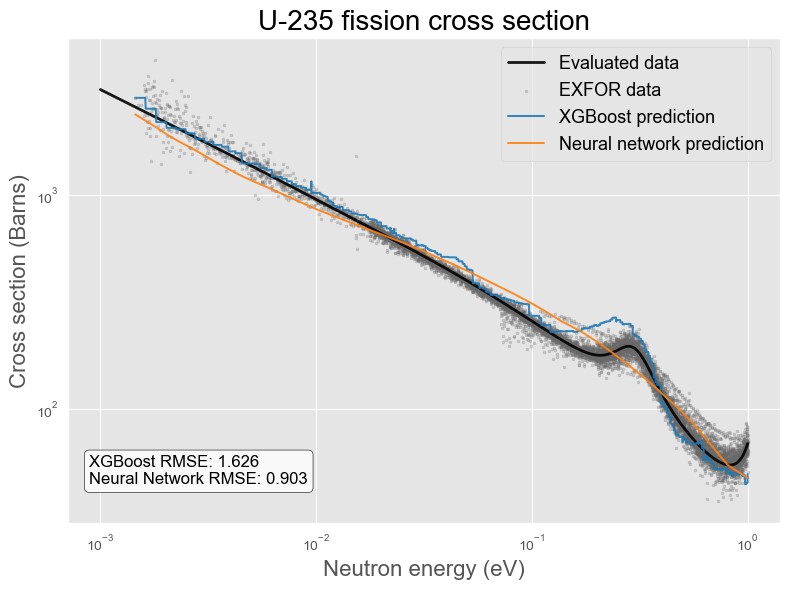

In [49]:
plt.style.use("ggplot")
plt.figure(figsize=(8, 6))

# Sort prediction data
df_xgb = pd.read_csv("../U235_thermal_pred.csv").sort_values("Energy")
df_nn = df__pred_nn.sort_values("Energy")   # if df_nn exists

# Evaluated data
plt.plot(E_eval, Xs_eval, color="black", linewidth=2.0, alpha=0.9, label="Evaluated data")

# EXFOR
plt.scatter(E_thermal, Xs_thermal, color="dimgray", s=4, alpha=0.25, label="EXFOR data")

# XGBoost
plt.plot(df_xgb["Energy"], df_xgb["Predicted_CrossSection"],
         color="tab:blue", linewidth=1.4, alpha=0.9, label="XGBoost prediction")

# Neural net
plt.plot(df_nn["Energy"], df_nn["Predicted_CrossSection"],
         color="tab:orange", linewidth=1.4, alpha=0.9, label="Neural network prediction")

plt.xscale("log")
plt.yscale("log")
plt.title("U-235 fission cross section", fontsize=20, color="black")
plt.xlabel("Neutron energy (eV)", fontsize=16)
plt.ylabel("Cross section (Barns)", fontsize=16)

# RMSE box in bottom left
plt.text(
    0.03, 0.08,
    "XGBoost RMSE: 1.626\nNeural Network RMSE: 0.903",
    transform=plt.gca().transAxes,
    fontsize=12,
    color="black",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))

plt.legend(loc="upper right", fontsize=13, labelcolor="black")
plt.tight_layout()
plt.savefig("fig3.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
df_holdout_res = pd.read_parquet("../data/df_holdout_resonance.parquet")
E_res = df_holdout_res["Energy"]
Xs_res = df_holdout_res["CrossSection"]
df_pred_xgb = pd.read_csv("../u235res_xgb.csv")
E_pred_xgb = df_pred_xgb["Energy"]
Xs_pred_xgb = df_pred_xgb["Predicted_CrossSection"]
df_pred_nn = pd.read_csv("../u235res_nn.csv")
E_pred_nn = df_pred_nn["Energy"]
Xs_pred_nn = df__pred_nn["Predicted_CrossSection"]
df_eval_res = df_fission[(df_fission["Energy"] >= 1) & (df_fission["Energy"] <= 10**4)]
E_eval = df_eval_res["Energy"]
Xs_eval = df_eval_res["CrossSection"]

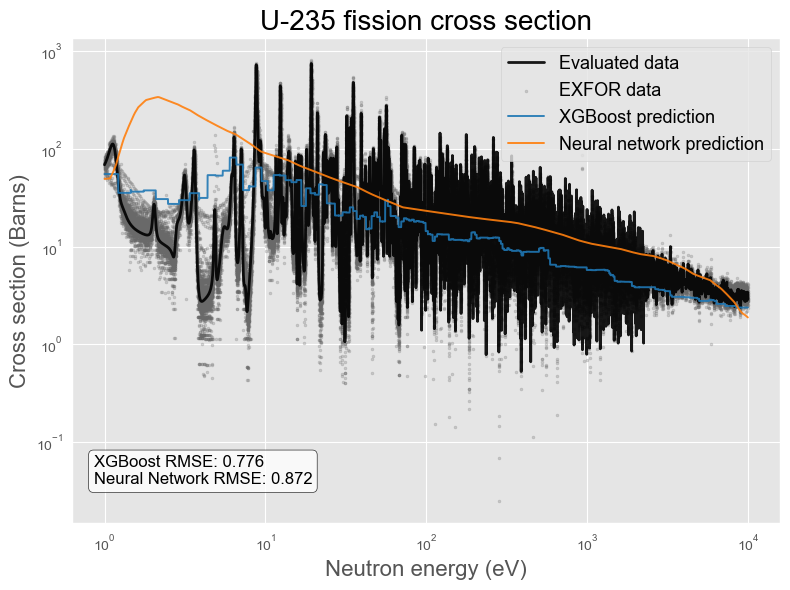

In [52]:
plt.style.use("ggplot")
plt.figure(figsize=(8, 6))

# Sort prediction data
df_xgb = pd.read_csv("../u235res_xgb.csv").sort_values("Energy")
df_nn = df_pred_nn.sort_values("Energy")  # if df_nn exists

# Evaluated data
plt.plot(E_eval, Xs_eval, color="black", linewidth=2.0, alpha=0.9, label="Evaluated data")

# EXFOR
plt.scatter(E_res, Xs_res, color="dimgray", s=4, alpha=0.25, label="EXFOR data")

# XGBoost
plt.plot(df_xgb["Energy"], df_xgb["Predicted_CrossSection"],
         color="tab:blue", linewidth=1.4, alpha=0.9, label="XGBoost prediction")

# Neural net
plt.plot(df_nn["Energy"], df_nn["Predicted_CrossSection"],
         color="tab:orange", linewidth=1.4, alpha=0.9, label="Neural network prediction")

plt.xscale("log")
plt.yscale("log")
plt.title("U-235 fission cross section", fontsize=20, color="black")
plt.xlabel("Neutron energy (eV)", fontsize=16)
plt.ylabel("Cross section (Barns)", fontsize=16)

# RMSE box in bottom left
plt.text(
    0.03, 0.08,
    "XGBoost RMSE: 0.776\nNeural Network RMSE: 0.872",
    transform=plt.gca().transAxes,
    fontsize=12,
    color="black",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))

plt.legend(loc="upper right", fontsize=13, labelcolor="black")
plt.tight_layout()
plt.savefig("fig4.png", dpi=300, bbox_inches="tight")
plt.show()